In [88]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
from scipy.stats import norm
np.set_printoptions(precision = 2)
plt.style.use("./deeplearning.mplstyle")

In [89]:
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0';
dlcolors = [dlblue, dlorange, dldarkred, dlmagenta, dlpurple]
dlc = dict(dlblue = '#0096ff', dlorange = '#FF9300', dldarkred='#C00000', dlmagenta='#FF40FF', dlpurple='#7030A0')

In [90]:
def load_house_data():
    data = np.loadtxt("./data/houses.txt", delimiter = ",", skiprows = 1)
    X = data[:, :4]
    y = data[:, 4]
    return X, y

In [91]:
def run_gradient_descent(X, y, iterations = 1000, alpha = 1e-6):
    m, n = X.shape

    #initialize parameters
    initial_w = np.zeros(n)
    initial_b = 0

    #run gradient descent
    w_out, b_out, hist_out = gradient_descent_houses(X, y, initial_w, initial_b, compute_cost, compute_gradient_matrix, alpha, iterations)
    print(f"w, b found by gradient descent: w: {w_out}, b: {b_out: 0.2f}")
    return w_out, b_out, hist_out

In [92]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range (m):
        f_wb_i = np.dot(X[i], w) + b
        cost += (f_wb_i - y[i]) ** 2
    cost /= (2 * m)
    return (np.squeeze(cost))

In [93]:
def compute_gradient_matrix(X, y, w, b):
    m, n = X.shape
    f_wb = X @ w + b
    e = f_wb - y
    dj_dw = (1 / m) * (X.T @ e)
    dj_db = (1 / m) * np.sum(e)
    return dj_db, dj_dw

In [94]:
def gradient_descent_houses(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn theta. Update theta by taking num_iters gradient steps with learning rate alpha
    """

    #number of training examples
    m = len(X)

    #an array to store values at each iteration primarily for grphing later
    hist = {}
    hist["cost"] = []
    hist["params"] = []
    hist["grads"] = []
    hist["iters"] = []

    w = copy.deepcopy(w_in)
    b = b_in
    save_interval = np.ceil(num_iters / 10000)
    print(f"Interation Cost    w0    w1    w2    w3    b    djdw0    djdw1    djdw2    djdw3    djdb")
    print(f"----------------|-------|----|-----|-----|-----|--------|--------|-------|--------|-----|")

    for i in range(num_iters):
        #calculate gradient and update parameters
        dj_db, dj_dw = gradient_function(X, y, w, b)

        #update parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        #save cost J, w, b at each interval for graphing
        if i == 0 or i % save_interval == 0:
            hist["cost"].append(cost_function(X, y, w, b))
            hist["params"].append([w, b])
            hist["grads"].append([dj_dw, dj_db])
            hist["iters"].append(i)

        #print cost every at interval 10 times or as many iterations <10
        if i % math.ceil(num_iters / 10) == 0:
            #print(f"Iterations {i : 4d}: Cost: {cost_function(X, y, w, b): 8.2f}")
            cst = cost_function(X, y, w, b)
            print(f"{i : 9d} {cst: 0.5e} {w[0]: 0.1e} {w[1]: 0.1e} {w[2]: 0.1e} {w[3]: 0.1e} {b: 0.1e} {dj_dw[0]: 0.1e} {dj_dw[1]: 0.1e} {dj_dw[2]: 0.1e} {dj_dw[3]: 0.1e} {dj_db: 0.1e}")

    return w, b, hist

In [95]:
def norm_plot(ax, data):
    scale = (np.max(data) - np.min(data)) * 0.2
    x = np.linspace(np.min(data) - scale, np.max(data) + scale, 50)
    _, bins, _ = ax.hist(data, x, color = 'xkcd:azure')

    #ax.set_ylabel("Count")
    mu = np.mean(data)
    std = np.std(data)
    dist = norm.pdf(bins, loc = mu, scale = std)
    axr = ax.twinx()
    axr.plot(bins, dist, color = 'orangered', lw = 2)
    axr.set_ylim(bottom = 0)
    axr.axis("off")

In [130]:
def plt_equal_scale(X_train, X_norm, y_train):
    fig, ax = plt.subplots(1, 2, figsize = (12, 5))
    prange = [[0.238-0.045, 0.238+0.045, 50], [-25.77326319-0.045, -25.77326319+0.045, 50], [-50000, 0, 50], [-1500, 0, 50], [0, 200000, 50]]
    w_best = np.array([0.23844318, -25.77326319, -58.11084634, -1.57727192])
    b_best = 235
    plt_contour_multi(X_train, y_train, w_best, b_best, ax[0], prange, 0, 1, title = 'Unnormalized, J(w, b), VS w[0], w[1]', xlabel = 'w[0] (size (sqft))', ylabel = 'w[1] (#bedrooms)')

    #
    w_best_n = np.array([111.1972, -16.75480051, -28.51530411, -37.17305735])
    b_best_n = 376.949151515151
    prange = [[111-50, 111+50, 75], [-16.75-50, -16.75+50, 75], [-28.5-8, -28.5+8, 50], [-37.1-16, -37.1+16, 50], [376-150, 376+150, 50]]
    plt_contour_multi(X_norm, y_train, w_best_n, b_best_n, ax[1], prange, 0, 1, title = 'Normalized, J(w, b), VS w[0], w[1]', xlabel = 'w[0] (normalized size (sqft))', ylabel = 'w[1] (normalized #bedrooms)')
    fig.suptitle("Cost contour with equal scale", fontsize = 18)
    #plt.tight_layout(rect = (0, 0, 1.05, 1.05))
    plt.tight_layout(rect = (0, 0, 1, 0.95))
    plt.show()

In [128]:
def plt_contour_multi(x, y, w, b, ax, prange, p1, p2, title = "", xlabel = "", ylabel = ""):
    contours = [1e2, 2e2, 3e2, 4e2, 5e2, 6e2, 7e2, 8e2, 1e3, 1.25e3, 1.5e3, 1e4, 1e5, 1e6, 1e7]
    px, py = np.meshgrid(np.linspace(*(prange[p1])), np.linspace(*(prange[p2])))
    z = np.zeros_like(px)
    for i in range(px.shape[0]):
        for j in range (px.shape[1]):
            w_ij = w
            b_ij = b
            if p1 <= 3:
                w_ij[p1] = px[i, j]
            if p1 == 4:
                b_ij = px[i, j]
            if p2 <= 3:
                w_ij[p2] = py[i, j]
            if p2 == 4:
                b_ij = py[i, j]
            z[i][j] = compute_cost(x, y, w_ij, b_ij)

    cs = ax.contour(px, py, z, contours, linewidths = 2, colors = [dlblue, dlorange, dldarkred, dlmagenta, dlpurple])
    ax.clabel(cs, inline = 1, fmt = "% 1.2e", fontsize = 10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize = 14)

In [98]:
def plt_cost_i_w(X, y, hist):
    ws = np.array([p[0] for p in hist["params"]])
    rng = max(abs(ws[:, 0].min()), abs(ws[:, 0].max()))
    wr = np.linspace(-rng+0.27, rng+0.27, 20)
    cst = [compute_cost(X, y, np.array([wr[i], -32, -67, -1.46]), 221) for i in range(len(wr))]
    fig, ax = plt.subplots(1, 2, figsize = (12, 3))
    ax[0].plot(hist["iters"], (hist["cost"]))
    ax[0].set_title("COST VS ITERATIONS")
    ax[0].set_ylabel("Cost")
    ax[0].set_xlabel("Iterations")

    ax[1].plot(wr, cst)
    ax[0].set_title("COST VS w[0]")
    ax[0].set_ylabel("Cost")
    ax[0].set_xlabel("w[0]")
    ax[1].plot(ws[:, 0], hist["cost"])
    plt.show()

<a name="toc_15456_5"></a>
## Gradient Descent With Multiple Variables
Here are the equations you developed in the last lab on gradient descent for multiple variables.:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j = 0..n-1}\newline
&b\ \ := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


## Learning Rate

The lectures discussed some of the issues related to setting the learning rate $\alpha$. The learning rate controls the size of the update to the parameters. See equation (1) above. It is shared by all the parameters.  

Let's run gradient descent and try a few settings of $\alpha$ on our data set

### $\alpha$ = 9.9e-7

The plot on the right shows the value of one of the parameters, $w_0$. At each iteration, it is overshooting the optimal value and as a result, cost ends up *increasing* rather than approaching the minimum. Note that this is not a completely accurate picture as there are 4 parameters being modified each pass rather than just one. This plot is only showing $w_0$ with the other parameters fixed at benign values. In this and later plots you may notice the blue and orange lines being slightly off.

The lectures discussed three different techniques: 
- Feature scaling, essentially dividing each positive feature by its maximum value, or more generally, rescale each feature by both its minimum and maximum values using (x-min)/(max-min). Both ways normalizes features to the range of -1 and 1, where the former method works for positive features which is simple and serves well for the lecture's example, and the latter method works for any features.
- Mean normalization: $x_i := \dfrac{x_i - \mu_i}{max - min} $ 
- Z-score normalization which we will explore below. 


### z-score normalization 
After z-score normalization, all features will have a mean of 0 and a standard deviation of 1.

To implement z-score normalization, adjust your input values as shown in this formula:
$$x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j} \tag{4}$$ 
where $j$ selects a feature or a column in the $\mathbf{X}$ matrix. $µ_j$ is the mean of all the values for feature (j) and $\sigma_j$ is the standard deviation of feature (j).
$$
\begin{align}
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \tag{5}\\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2  \tag{6}
\end{align}
$$

>**Implementation Note:** When normalizing the features, it is important
to store the values used for normalization - the mean value and the standard deviation used for the computations. After learning the parameters
from the model, we often want to predict the prices of houses we have not
seen before. Given a new x value (living room area and number of bed-
rooms), we must first normalize x using the mean and standard deviation
that we had previously computed from the training set.

**Implementation**

In [99]:
#load the dataset
X_train, y_train = load_house_data()
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

Let's view the dataset and it's features by plotting each features vs price

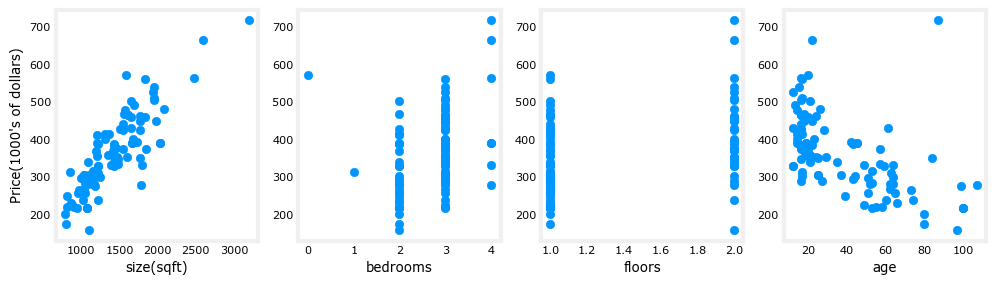

In [100]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price(1000's of dollars)")
plt.show()

# Gradient Descent with Multiple Variables & setting $\alpha$

Interation Cost    w0    w1    w2    w3    b    djdw0    djdw1    djdw2    djdw3    djdb
----------------|-------|----|-----|-----|-----|--------|--------|-------|--------|-----|
        0  9.55884e+04  5.5e-01  1.0e-03  5.1e-04  1.2e-02  3.6e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1  1.28213e+05 -8.8e-02 -1.7e-04 -1.0e-04 -3.4e-03 -4.8e-05  6.4e+05  1.2e+03  6.2e+02  1.6e+04  4.1e+02
        2  1.72159e+05  6.5e-01  1.2e-03  5.9e-04  1.3e-02  4.3e-04 -7.4e+05 -1.4e+03 -7.0e+02 -1.7e+04 -4.9e+02
        3  2.31358e+05 -2.1e-01 -4.0e-04 -2.3e-04 -7.5e-03 -1.2e-04  8.6e+05  1.6e+03  8.3e+02  2.1e+04  5.6e+02
        4  3.11100e+05  7.9e-01  1.4e-03  7.1e-04  1.5e-02  5.3e-04 -1.0e+06 -1.8e+03 -9.5e+02 -2.3e+04 -6.6e+02
        5  4.18517e+05 -3.7e-01 -7.1e-04 -4.0e-04 -1.3e-02 -2.1e-04  1.2e+06  2.1e+03  1.1e+03  2.8e+04  7.5e+02
        6  5.63212e+05  9.7e-01  1.7e-03  8.7e-04  1.8e-02  6.6e-04 -1.3e+06 -2.5e+03 -1.3e+03 -3.1e+04 -8.8e+02
        7  7.58122e+05 -5.8e-0

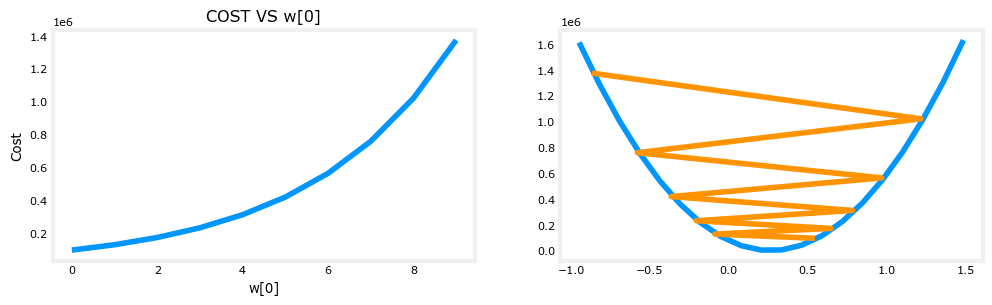

In [101]:
#set alpha to 9.9e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.9e-7)
#plotting the result
plt_cost_i_w(X_train, y_train, hist)

In the above case cost increases in each iteration. 
Let's try with a lower learning rate
$\alpha$ = 9e-7 

Interation Cost    w0    w1    w2    w3    b    djdw0    djdw1    djdw2    djdw3    djdb
----------------|-------|----|-----|-----|-----|--------|--------|-------|--------|-----|
        0  6.64616e+04  5.0e-01  9.1e-04  4.7e-04  1.1e-02  3.3e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1  6.18990e+04  1.8e-02  2.1e-05  2.0e-06 -7.9e-04  1.9e-05  5.3e+05  9.8e+02  5.2e+02  1.3e+04  3.4e+02
        2  5.76572e+04  4.8e-01  8.6e-04  4.4e-04  9.5e-03  3.2e-04 -5.1e+05 -9.3e+02 -4.8e+02 -1.1e+04 -3.4e+02
        3  5.37137e+04  3.4e-02  3.9e-05  2.8e-06 -1.6e-03  3.8e-05  4.9e+05  9.1e+02  4.8e+02  1.2e+04  3.2e+02
        4  5.00474e+04  4.6e-01  8.2e-04  4.1e-04  8.0e-03  3.2e-04 -4.8e+05 -8.7e+02 -4.5e+02 -1.1e+04 -3.1e+02
        5  4.66388e+04  5.0e-02  5.6e-05  2.5e-06 -2.4e-03  5.6e-05  4.6e+05  8.5e+02  4.5e+02  1.2e+04  2.9e+02
        6  4.34700e+04  4.5e-01  7.8e-04  3.8e-04  6.4e-03  3.2e-04 -4.4e+05 -8.1e+02 -4.2e+02 -9.8e+03 -2.9e+02
        7  4.05239e+04  6.4e-0

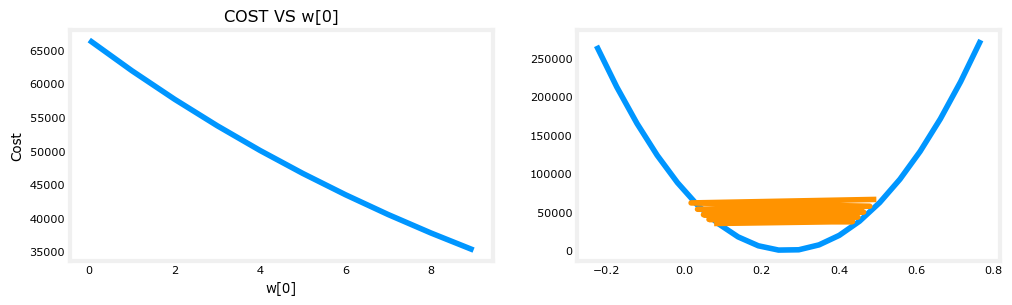

In [102]:
#set alpha to 9e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9e-7)
#plotting the result
plt_cost_i_w(X_train, y_train, hist)

1. cost decreading as it should.
2. w0 still ascillating around the minimum, but the cost is decreasing with every iteration rahter than increasing.

Let's try with a bit more lower value of $\alpha$. 
Let $\alpha$ = 1e-7

Interation Cost    w0    w1    w2    w3    b    djdw0    djdw1    djdw2    djdw3    djdb
----------------|-------|----|-----|-----|-----|--------|--------|-------|--------|-----|
        0  4.42313e+04  5.5e-02  1.0e-04  5.2e-05  1.2e-03  3.6e-05 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1  2.76461e+04  9.8e-02  1.8e-04  9.2e-05  2.2e-03  6.5e-05 -4.3e+05 -7.9e+02 -4.0e+02 -9.5e+03 -2.8e+02
        2  1.75102e+04  1.3e-01  2.4e-04  1.2e-04  2.9e-03  8.7e-05 -3.4e+05 -6.1e+02 -3.1e+02 -7.3e+03 -2.2e+02
        3  1.13157e+04  1.6e-01  2.9e-04  1.5e-04  3.5e-03  1.0e-04 -2.6e+05 -4.8e+02 -2.4e+02 -5.6e+03 -1.8e+02
        4  7.53002e+03  1.8e-01  3.3e-04  1.7e-04  3.9e-03  1.2e-04 -2.1e+05 -3.7e+02 -1.9e+02 -4.2e+03 -1.4e+02
        5  5.21639e+03  2.0e-01  3.5e-04  1.8e-04  4.2e-03  1.3e-04 -1.6e+05 -2.9e+02 -1.5e+02 -3.1e+03 -1.1e+02
        6  3.80242e+03  2.1e-01  3.8e-04  1.9e-04  4.5e-03  1.4e-04 -1.3e+05 -2.2e+02 -1.1e+02 -2.3e+03 -8.6e+01
        7  2.93826e+03  2.2e-0

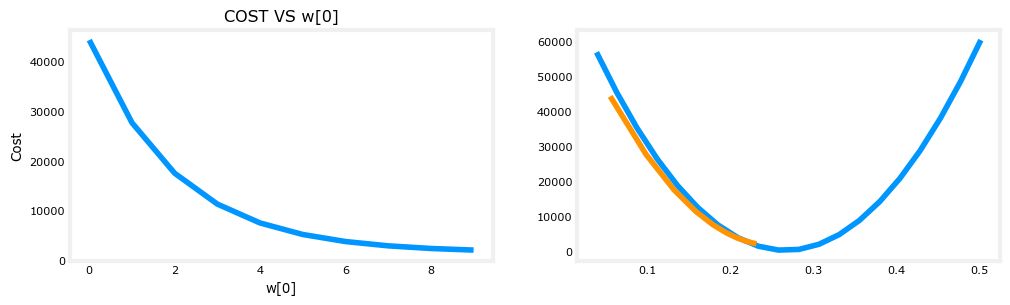

In [103]:
#set alpha to 1e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 1e-7)
#plotting the result
plt_cost_i_w(X_train, y_train, hist)

1. Cost decreasing as it should.
2. w0 approaching minimum without occilation.
3. dj_dw0 negative throughout
4. This should coverge.

# Feature Scaling with Z-Score Normalization

In [104]:
def zscore_normalize_features(X):
    """
    Compute X, z-score normalized by column
    Args:
        X (ndarray, (m, n)): input data, m examples, n features
    Returns:
        X_norm (ndarray (m, n)) : input normalized by column
        mu (ndarray (n, )) : mean of each features
        signma (ndarray (n, )) : S.D. of each features
    """
    #find the mean of each column/features
    mu = np.mean(X, axis = 0)
    #find the S.D of each column/features
    sigma = np.std(X, axis = 0)

    X_norm = (X - mu)/sigma

    return X_norm, mu, sigma

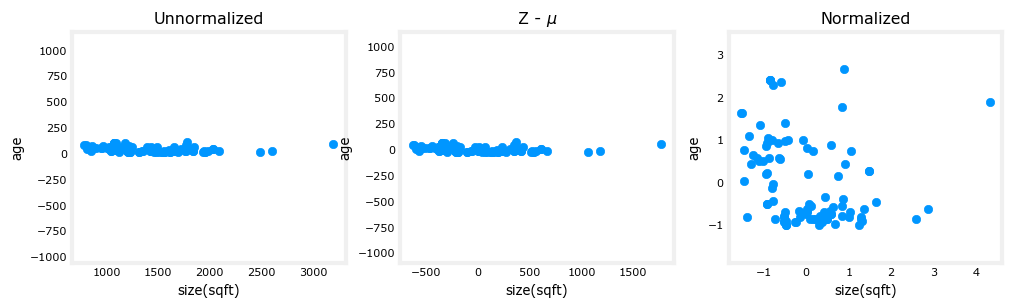

In [105]:
#plotting transformation step by step
mu = np.mean(X_train, axis = 0)
sigma = np.std(X_train, axis = 0)
X_mean = X_train - mu
X_norm = (X_train - mu) / sigma

fig, ax = plt.subplots(1, 3, figsize = (12, 3))
ax[0].scatter(X_train[:, 0], X_train[:, 3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[0].set_title("Unnormalized")
ax[0].axis("equal")

ax[1].scatter(X_mean[:, 0], X_mean[:, 3])
ax[1].set_xlabel(X_features[0])
ax[1].set_ylabel(X_features[3])
ax[1].set_title(r"Z - $\mu$")
ax[1].axis("equal")

ax[2].scatter(X_norm[:, 0], X_norm[:, 3])
ax[2].set_xlabel(X_features[0])
ax[2].set_ylabel(X_features[3])
ax[2].set_title("Normalized")
ax[2].axis("equal")

plt.show()

In [106]:
#normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to peak range by column in row X: {np.ptp(X_train, axis = 0)}")
print(f"Peak to peak range by column in normalized X: {np.ptp(X_norm, axis = 0)}")

X_mu = [1.42e+03 2.72e+00 1.38e+00 3.84e+01], 
X_sigma = [411.62   0.65   0.49  25.78]
Peak to peak range by column in row X: [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to peak range by column in normalized X: [5.85 6.14 2.06 3.69]


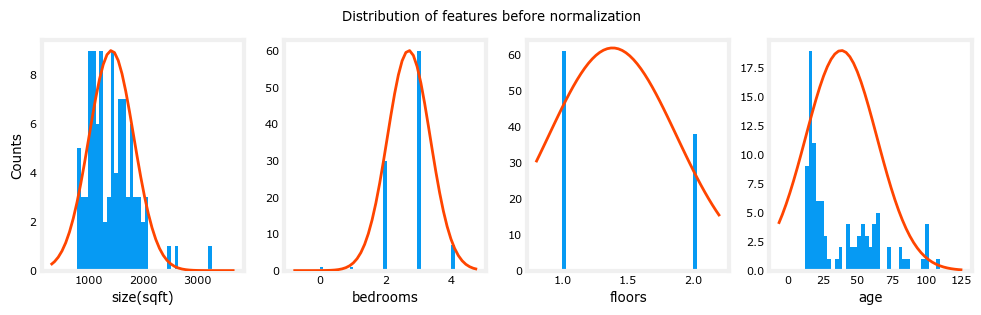

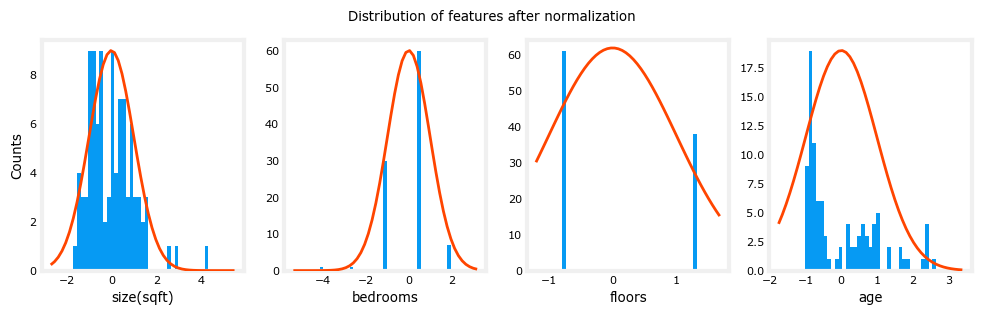

In [109]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    norm_plot(ax[i],X_train[:, i])
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Counts")
fig.suptitle("Distribution of features before normalization")
plt.show()

fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    norm_plot(ax[i],X_norm[:, i])
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Counts")
fig.suptitle("Distribution of features after normalization")
plt.show()

In [110]:
w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1e-1)

Interation Cost    w0    w1    w2    w3    b    djdw0    djdw1    djdw2    djdw3    djdb
----------------|-------|----|-----|-----|-----|--------|--------|-------|--------|-----|
        0  5.76170e+04  8.9e+00  3.0e+00  3.3e+00 -6.0e+00  3.6e+01 -8.9e+01 -3.0e+01 -3.3e+01  6.0e+01 -3.6e+02
      100  2.21086e+02  1.1e+02 -2.0e+01 -3.1e+01 -3.8e+01  3.6e+02 -9.2e-01  4.5e-01  5.3e-01 -1.7e-01 -9.6e-03
      200  2.19209e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.0e-02  1.5e-02  1.7e-02 -6.0e-03 -2.6e-07
      300  2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.0e-03  5.1e-04  5.7e-04 -2.0e-04 -6.9e-12
      400  2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.4e-05  1.7e-05  1.9e-05 -6.6e-06 -2.7e-13
      500  2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.1e-06  5.6e-07  6.2e-07 -2.2e-07 -2.7e-13
      600  2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.7e-08  1.9e-08  2.1e-08 -7.3e-09 -2.6e-13
      700  2.19207e+02  1.1e+0

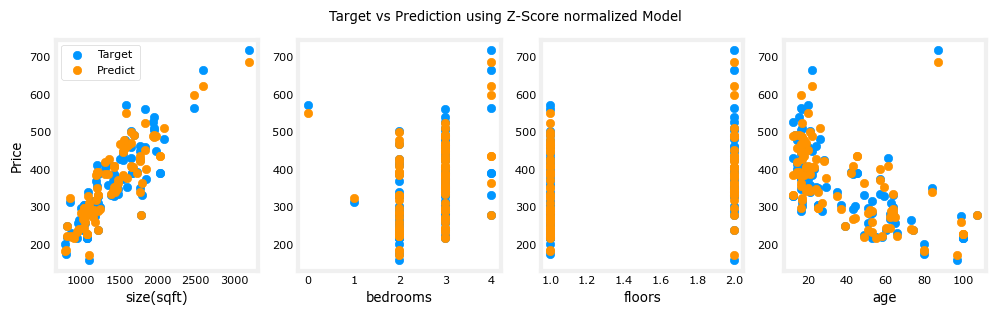

In [120]:
#predict the target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range (m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

#plot predictions & targets vs original features
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label = 'Target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:, i], yp, color = dlc["dlorange"], label = 'Predict')

ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("Target vs Prediction using Z-Score normalized Model")
plt.show()

## PREDICTION

Let's predict the price of a house with 1200 sqft, 3 bedrooms, 1 floors, 40 years old

In [126]:
#normalize out examples
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f"Predicted price of a house with 1200 sq. ft., 3 bedrooms, 1 floor and 40 years old = $ {x_house_predict * 1000}")

[-0.53  0.43 -0.79  0.06]
Predicted price of a house with 1200 sq. ft., 3 bedrooms, 1 floor and 40 years old = $ 318709.0923199992


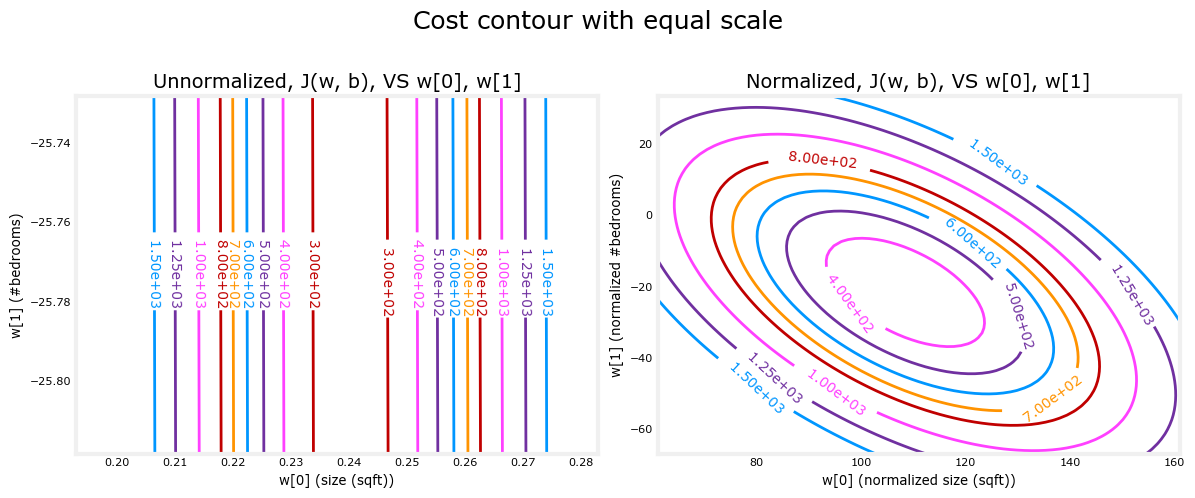

In [131]:
plt_equal_scale(X_train, X_norm, y_train)